# 06 — Exponential Smoothing: SES, Holt, and Holt–Winters

## From simple averages to a model with memory

**Research question:**

> How does the effectiveness of AI-based inventory optimization change from traditional forecasting models to large language model–based approaches?

This notebook studies the second level of the model ladder: **exponential smoothing**.

The previous notebook established three baselines:

- **Naive:** tomorrow equals the last observed value.
- **Seasonal Naive:** next week repeats the last weekly cycle.
- **Moving Average:** tomorrow equals the average of the last *W* observations.

Exponential smoothing asks a more refined question:

> Can we give recent observations more influence while still retaining a controlled memory of older observations?

This is not a leaderboard-only exercise. For every model, we explain the mechanism, assumptions, failure modes, and possible inventory consequences before looking at the results.

**Important:** this notebook does not change either dataset or the frozen experiment design. It uses the same 500 M5 series, all 500 Store Item series, common window, 8 origins, 28-day horizon, and four forecasting metrics.

---
## 1. What this notebook decides

### Research question

How much of the baseline error can be reduced by models that explicitly estimate a changing demand level, trend, and weekly seasonality?

### Why it matters

A model can have a lower error but still be a poor inventory model if it reacts too slowly, overreacts to noise, or creates unstable replenishment signals. We therefore evaluate both numerical accuracy and the behavior that would matter to an inventory planner.

### Layman explanation

The baselines use very simple rules. Exponential smoothing is like keeping a running opinion about demand:

- recent sales matter more;
- older sales still leave a faint memory;
- the model can separately track the average level, the direction of movement, and the weekly rhythm.

The three models studied are:

| Model | Main idea |
|---|---|
| **SES** | Track the current level |
| **Holt / DES** | Track level plus trend |
| **Holt–Winters / TES** | Track level, trend, and seasonality |

---
## 2. Frozen experiment contract

All models in this notebook must use the same experimental conditions as Notebook 05.

| Element | Frozen value |
|---|---|
| M5 | 500 stratified representative series |
| Store Item Demand | All 500 series |
| Common window | 2013-01-01 → 2016-05-22 |
| Training history available | Up to the current forecast origin |
| Validation | 2015-11-01 → 2016-02-28 |
| Test | 2016-03-01 → 2016-05-22 |
| Forecast horizon | 28 days |
| Rolling origins | 8 weekly origins |
| Metrics | MAE, RMSE, sMAPE, WAPE |
| Seed | 42 |

**Leakage rule:** at origin *t*, fitting and parameter decisions may use only observations dated before *t*. The next 28 actual observations are reserved for evaluation.

In [1]:
import json
import pathlib
import time
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

PROJ = pathlib.Path('..')
RAW_M5 = PROJ / '02_data/dataset_01_m5/raw'
RAW_SIT = PROJ / '02_data/dataset_02_store_item_demand/raw'
PROC_SIT = PROJ / '02_data/dataset_02_store_item_demand/processed'
RES = PROJ / '06_results/exponential_smoothing'
FIG = PROJ / '07_figures/exponential_smoothing'
EDU = PROJ / '07_figures/model_explanations/exponential_smoothing'
for d in [RES, FIG, EDU]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
C1, C2, C3, C4, CN = '#0072B2', '#D55E00', '#009E73', '#CC79A7', '#999999'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

H = 28
SEASONAL_PERIOD = 7
COMMON_START = pd.Timestamp('2013-01-01')
COMMON_END = pd.Timestamp('2016-05-22')
TRAIN_END = pd.Timestamp('2015-10-31')
VAL_START = pd.Timestamp('2015-11-01')
VAL_END = pd.Timestamp('2016-02-28')
TEST_START = pd.Timestamp('2016-03-01')
TEST_END = pd.Timestamp('2016-05-22')
ORIGIN_DATES = [TEST_START + pd.Timedelta(days=7*i) for i in range(8)]
DATES = pd.date_range(COMMON_START, COMMON_END, freq='D')
DATE_TO_OFFSET = {d: i for i, d in enumerate(DATES)}
TRAIN_END_OFFSET = DATE_TO_OFFSET[TRAIN_END] + 1
VAL_START_OFFSET = DATE_TO_OFFSET[VAL_START]
VAL_END_OFFSET = DATE_TO_OFFSET[VAL_END] + 1
TEST_START_OFFSET = DATE_TO_OFFSET[TEST_START]
TEST_END_OFFSET = DATE_TO_OFFSET[TEST_END] + 1

print('Environment ready.')
print('Common days:', len(DATES), '| origins:', len(ORIGIN_DATES), '| horizon:', H)
print('Output directories:', RES, FIG, EDU)

Environment ready.
Common days: 1238 | origins: 8 | horizon: 28
Output directories: ..\06_results\exponential_smoothing ..\07_figures\exponential_smoothing ..\07_figures\model_explanations\exponential_smoothing


### Reading the environment cell

The code above creates separate locations for:

- **experimental results** (`06_results/exponential_smoothing/`);
- **experimental figures** (`07_figures/exponential_smoothing/`);
- **educational figures** (`07_figures/model_explanations/exponential_smoothing/`).

This separation prevents a teaching diagram from being confused with a result used in the research report.

---
## 3. Loading both datasets without changing them

### What we're doing

Load the M5 evaluation file and the processed Store Item Demand Parquet file, then align both to the verified common calendar.

### Why it matters

M5 is stored in wide format (`d_1`, `d_2`, …), while Store Item Demand is stored in long format. Forecasting functions should receive the same internal representation: one row per series and one column per calendar day.

### Layman explanation

The two datasets use different spreadsheet layouts. We convert only their in-memory copies into the same shape so that the models receive a fair input. The raw files themselves are never overwritten.

In [2]:
# M5: evaluation file is required because origins 5–8 extend beyond d_1913.
cal = pd.read_csv(RAW_M5 / 'calendar.csv', parse_dates=['date'])
cal_d_to_date = dict(zip(cal['d'], cal['date']))
cal_date_to_d = {v: k for k, v in cal_d_to_date.items()}
assert cal_date_to_d[COMMON_START] == 'd_704'
assert cal_date_to_d[COMMON_END] == 'd_1941'

m5_eval = pd.read_csv(RAW_M5 / 'sales_train_evaluation.csv')
with open(PROJ / '05_experiments/m5_series_selection.json', encoding='utf-8') as fh:
    selection = json.load(fh)
selected_validation_ids = selection['m5_series']
selected_eval_ids = [sid.replace('_validation', '_evaluation') for sid in selected_validation_ids]
assert len(selected_eval_ids) == 500
m5_sel = m5_eval.set_index('id').loc[selected_eval_ids]
m5_d_cols_common = [cal_date_to_d[d] for d in DATES]
X_m5 = m5_sel[m5_d_cols_common].to_numpy(dtype=float)
assert X_m5.shape == (500, 1238)

# Store Item Demand: use processed parquet produced by Notebook 02b.
sit = pd.read_parquet(PROC_SIT / 'store_item_demand_daily.parquet')
sit['date'] = pd.to_datetime(sit['date'])
sit_window = sit[sit['date'].between(COMMON_START, COMMON_END)].copy()
sit_pivot = sit_window.pivot_table(index='date', columns=['store', 'item'], values='sales', aggfunc='sum').sort_index()
assert sit_pivot.shape == (1238, 500)
assert sit_pivot.isna().sum().sum() == 0
X_sit = sit_pivot.to_numpy(dtype=float).T
sit_ids = ['S%02d_I%02d' % (int(store), int(item)) for store, item in sit_pivot.columns]

DATASETS = {'m5': X_m5, 'store_item_demand': X_sit}
SERIES_IDS = {'m5': selected_eval_ids, 'store_item_demand': sit_ids}

print('M5 matrix:', X_m5.shape, '| first id:', selected_eval_ids[0])
print('Store Item matrix:', X_sit.shape, '| first id:', sit_ids[0])
print('Common calendar:', DATES.min().date(), 'to', DATES.max().date())

M5 matrix: (500, 1238) | first id: FOODS_1_098_CA_3_evaluation
Store Item matrix: (500, 1238) | first id: S01_I01
Common calendar: 2013-01-01 to 2016-05-22


### Data-loading interpretation

Both matrices have shape **500 × 1,238**:

- 500 rows = the series evaluated in this experiment;
- 1,238 columns = the verified common calendar days.

For M5, the selection file stores validation-suffixed IDs; the code maps them to the matching evaluation IDs. This is necessary because the evaluation file contains the actual future observations for origins 5–8. The mapping changes no series identity and does not alter M5 data.

---
## 4. Periods, origins, and the leakage boundary

### What we're doing

Create offsets for the frozen train, validation, and test periods, then verify every test origin has a complete 28-day ground-truth window.

### Why it matters

The full evaluation file exists locally, but the model must behave as though it does not know the future. At each origin, only the prefix before the origin is history; the following 28 values are labels used after forecasting.

### Layman explanation

Imagine stopping a movie at eight different points. At each stop, the model may watch only the movie before the stop. The next 28 scenes are hidden until we score its prediction.

In [3]:
origin_rows = []
for origin_id, origin_date in enumerate(ORIGIN_DATES, start=1):
    origin_offset = DATE_TO_OFFSET[origin_date]
    fc_dates = pd.date_range(origin_date, periods=H, freq='D')
    assert fc_dates[-1] <= TEST_END
    origin_rows.append({
        'origin_id': origin_id,
        'origin_date': origin_date,
        'history_end': origin_date - pd.Timedelta(days=1),
        'forecast_start': fc_dates[0],
        'forecast_end': fc_dates[-1],
        'history_columns': origin_offset,
        'actual_test_days': len(fc_dates),
    })
origins_df = pd.DataFrame(origin_rows)
print(origins_df.to_string(index=False))
assert (origins_df['actual_test_days'] == H).all()
assert origins_df['forecast_end'].max() <= TEST_END

# The frozen design deliberately uses expanding history up to each origin.
print('All origins have exactly 28 ground-truth observations: YES')
print('Forecast windows overlap by 21 days between adjacent weekly origins: YES')

 origin_id origin_date history_end forecast_start forecast_end  history_columns  actual_test_days
         1  2016-03-01  2016-02-29     2016-03-01   2016-03-28             1155                28
         2  2016-03-08  2016-03-07     2016-03-08   2016-04-04             1162                28
         3  2016-03-15  2016-03-14     2016-03-15   2016-04-11             1169                28
         4  2016-03-22  2016-03-21     2016-03-22   2016-04-18             1176                28
         5  2016-03-29  2016-03-28     2016-03-29   2016-04-25             1183                28
         6  2016-04-05  2016-04-04     2016-04-05   2016-05-02             1190                28
         7  2016-04-12  2016-04-11     2016-04-12   2016-05-09             1197                28
         8  2016-04-19  2016-04-18     2016-04-19   2016-05-16             1204                28
All origins have exactly 28 ground-truth observations: YES
Forecast windows overlap by 21 days between adjacent weekly

### Origin interpretation

The eight forecast windows overlap because origins are seven days apart while each forecast is 28 days long. That overlap is intentional: it estimates how a model behaves repeatedly as time advances.

The model never receives the `actual` values for its forecast window during fitting. The evaluator reads those values only after the forecast is produced.

---
# 5. SES — Simple Exponential Smoothing

## 5.1 What problem does SES solve?

### Starting limitation

The Moving Average averages the most recent *W* observations equally. That creates an awkward choice:

- a short window reacts quickly but is noisy;
- a long window is stable but forgets a genuine change too slowly.

SES avoids a hard cutoff. It gives the newest observation the largest weight, and older observations receive progressively smaller weights.

### One idea to remember

> **SES maintains one moving estimate of the current demand level.**

### Layman analogy

Suppose a shopkeeper estimates tomorrow's demand. They listen most carefully to today's sales, somewhat to yesterday's, and only faintly to sales from last week. They do not throw the older information away; they simply trust it less.

## 5.2 How SES works — step by step

1. Start with an initial level estimate.
2. Observe today's demand.
3. Compare today's demand with the previous level estimate.
4. Move the level toward today's observation.
5. Use the updated level as the forecast for future days.

```
previous level + new observation
             ↓
       weighted update
             ↓
       updated level
             ↓
       future forecast
```

SES has no separate trend or seasonal state. Its entire memory is one number: the current level.

## 5.3 SES mathematics

The level update is:

$$
\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}
$$

The *h*-step forecast is:

$$
\hat{y}_{t+h|t} = \ell_t
$$

Where:

- $y_t$ = observed demand at time $t$;
- $\ell_t$ = estimated demand level after observing $y_t$;
- $\alpha$ = smoothing parameter, between 0 and 1;
- $\hat{y}_{t+h|t}$ = forecast made at time $t$ for a future step.

The equation is a weighted compromise. If $\alpha$ is large, today's observation pulls the level strongly. If $\alpha$ is small, the previous level remains dominant.

Expanding the recursion shows the memory:

$$
\ell_t = \alpha y_t + \alpha(1-\alpha)y_{t-1} + \alpha(1-\alpha)^2y_{t-2} + \cdots
$$

Older observations never disappear instantly; their influence decays geometrically.

## 5.4 SES parameters

| Parameter | Controls | Small value | Large value |
|---|---|---|---|
| $\alpha$ | Responsiveness to new demand | Smooth, slow, resistant to noise | Fast, reactive, sensitive to spikes |
| Initial level | Starting estimate | Can create early bias if poorly chosen | Same issue; effect fades with history |

We will not choose $\alpha$ from the test set. A small candidate grid is selected using validation data only.

In [4]:
# Tiny hand-worked SES example
example = [10, 12, 11, 15, 14]
alpha = 0.5
level = example[0]
rows = [{'day': 1, 'actual': example[0], 'level_after_update': level}]
for day, value in enumerate(example[1:], start=2):
    level = alpha * value + (1 - alpha) * level
    rows.append({'day': day, 'actual': value, 'level_after_update': level})
example_df = pd.DataFrame(rows)
print(example_df.to_string(index=False))
print(f'Next forecast = last level = {level:.2f}')

 day  actual  level_after_update
   1      10                10.0
   2      12                11.0
   3      11                11.0
   4      15                13.0
   5      14                13.5
Next forecast = last level = 13.50


### SES numerical example interpretation

With $\alpha=0.5$, the final update is:

$$
\ell_5 = 0.5(14) + 0.5(12.875) = 13.4375
$$

So SES forecasts the next day at approximately **13.44 units**. The forecast is not simply yesterday's 14 and not the unweighted average of all five days (12.4). It is a recency-weighted compromise.

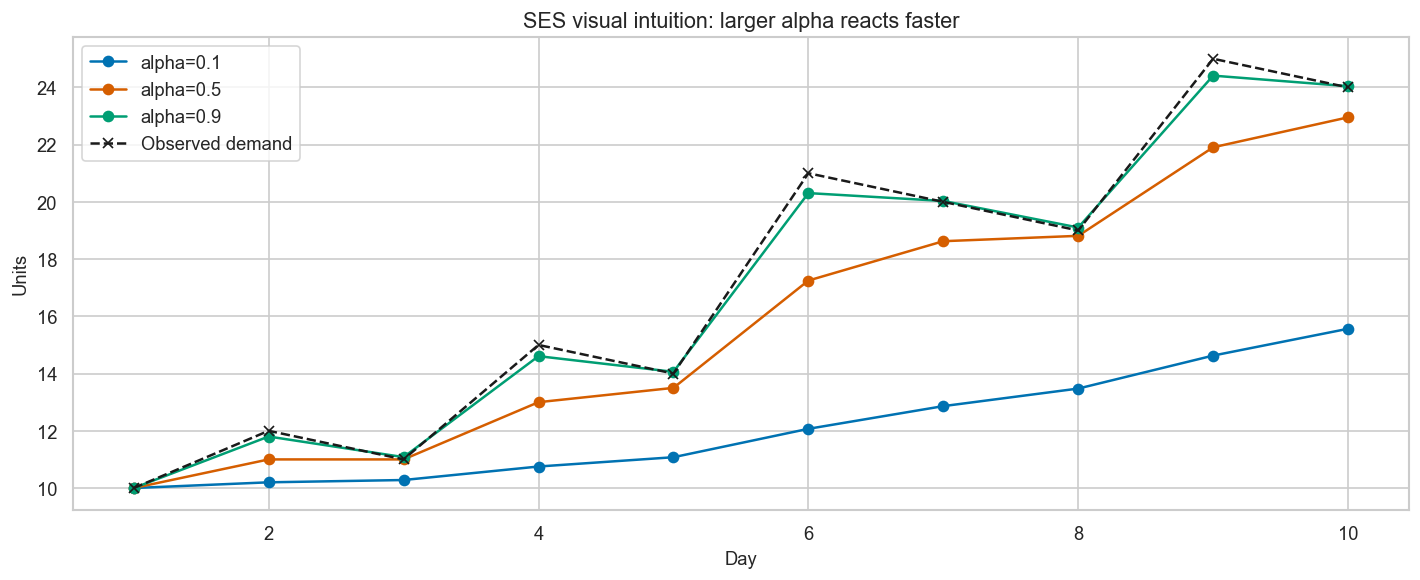

Saved: ..\07_figures\model_explanations\exponential_smoothing\01_ses_alpha_sensitivity.png


In [5]:
# Visual intuition: alpha changes responsiveness
fig, ax = plt.subplots(figsize=(12, 5))
series = np.array([10, 12, 11, 15, 14, 21, 20, 19, 25, 24], dtype=float)
for alpha, color in [(0.1, C1), (0.5, C2), (0.9, C3)]:
    states = [series[0]]
    for value in series[1:]:
        states.append(alpha * value + (1 - alpha) * states[-1])
    ax.plot(range(1, len(series)+1), states, marker='o', label=f'alpha={alpha}', color=color)
ax.plot(range(1, len(series)+1), series, 'k--', marker='x', label='Observed demand')
ax.set_title('SES visual intuition: larger alpha reacts faster')
ax.set_xlabel('Day')
ax.set_ylabel('Units')
ax.legend()
plt.tight_layout()
plt.savefig(EDU / '01_ses_alpha_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', EDU / '01_ses_alpha_sensitivity.png')

### Reading the SES parameter chart

The low-$\alpha$ line is stable but lags behind the sudden increase around day 6. The high-$\alpha$ line follows the spike quickly but also follows noise more aggressively.

For inventory, this is a direct trade-off:

- too little responsiveness can under-order after a genuine demand increase;
- too much responsiveness can over-order after a one-day spike.

### SES assumptions

| Assumption | Why it matters | If violated |
|---|---|---|
| Demand has a meaningful current level | SES forecasts that level forward | A changing trend creates systematic lag |
| No separate trend is required | The level alone should be sufficient | Forecasts flatten when demand is rising or falling |
| Observations are informative | Recent values should update belief | Outliers can move the level too far |

**What SES can capture:** changing level and short-lived noise.

**What SES cannot capture explicitly:** trend, weekly seasonality, promotions, or structural breaks.

---
# 6. Holt / DES — Double Exponential Smoothing

## 6.1 What problem does DES solve?

SES has one major limitation: if demand is steadily increasing, it keeps updating the level but has no explicit memory of direction. Its forecast becomes flat and tends to lag.

DES adds a second state — a trend estimate.

### One idea to remember

> **DES maintains both the current level and the current direction of travel.**

### Layman analogy

SES tells us the shop is currently selling about 20 units per day. DES also asks: are we moving upward by roughly two units per day, or downward by one?

## 6.2 DES architecture and algorithm

DES maintains two internal states:

- **level** $\ell_t$: the current baseline demand;
- **trend** $b_t$: the estimated change in that baseline per day.

```
new demand
   ↓
update level ─────┐
                  ├──→ level + future trend = forecast
update trend ─────┘
```

At each new observation:

1. update the level using the old level plus the old trend;
2. compare the new level with the old level to update the trend;
3. extrapolate level and trend into the future.

## 6.3 DES mathematics

The additive-trend Holt equations are:

$$
\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1}+b_{t-1})
$$

$$
 b_t = \beta(\ell_t-\ell_{t-1}) + (1-\beta)b_{t-1}
$$

$$
\hat{y}_{t+h|t} = \ell_t + h b_t
$$

Where:

- $\ell_t$ = updated level;
- $b_t$ = updated trend per day;
- $\alpha$ = level responsiveness;
- $\beta$ = trend responsiveness;
- $h$ = forecast step ahead;
- $y_t$ = observed demand.

The first equation asks: what is today's level after considering today's observation and yesterday's projected level? The second asks: how much did the level move, and should that movement become the new trend?

## 6.4 DES parameters, strengths, and limitations

| Parameter | Controls | Small value | Large value |
|---|---|---|---|
| $\alpha$ | Level response | Stable level, slow reaction | Fast response to new observations |
| $\beta$ | Trend response | Stable trend, slow adaptation | Trend changes quickly, can be noisy |

**Can capture:** level plus approximately linear trend.

**Cannot capture explicitly:** weekly seasonality, nonlinear trends, promotions, or intermittent demand's special zero structure.

**Inventory implication:** a positive trend raises future order-up-to demand; a false trend can create excess stock. A negative trend can reduce holding but increases stockout risk if the decline reverses.

In [6]:
# Tiny hand-worked DES example
values = [10, 12, 11, 15, 14]
alpha, beta = 0.5, 0.5
level = values[0]
trend = values[1] - values[0]
rows = [{'day': 1, 'actual': values[0], 'level': level, 'trend': trend}]
for day, value in enumerate(values[1:], start=2):
    old_level = level
    level = alpha * value + (1 - alpha) * (level + trend)
    trend = beta * (level - old_level) + (1 - beta) * trend
    rows.append({'day': day, 'actual': value, 'level': level, 'trend': trend})
des_example = pd.DataFrame(rows)
print(des_example.round(3).to_string(index=False))
print(f'One-step-ahead forecast = {level + trend:.3f}')

 day  actual  level  trend
   1      10 10.000  2.000
   2      12 12.000  2.000
   3      11 12.500  1.250
   4      15 14.375  1.562
   5      14 14.969  1.078
One-step-ahead forecast = 16.047


### DES numerical example interpretation

DES ends with two numbers rather than one. The level summarizes where demand is now; the trend summarizes its direction. The next forecast is their sum.

If the trend state is positive, the model will forecast above the current level. This is exactly the capability SES does not have.

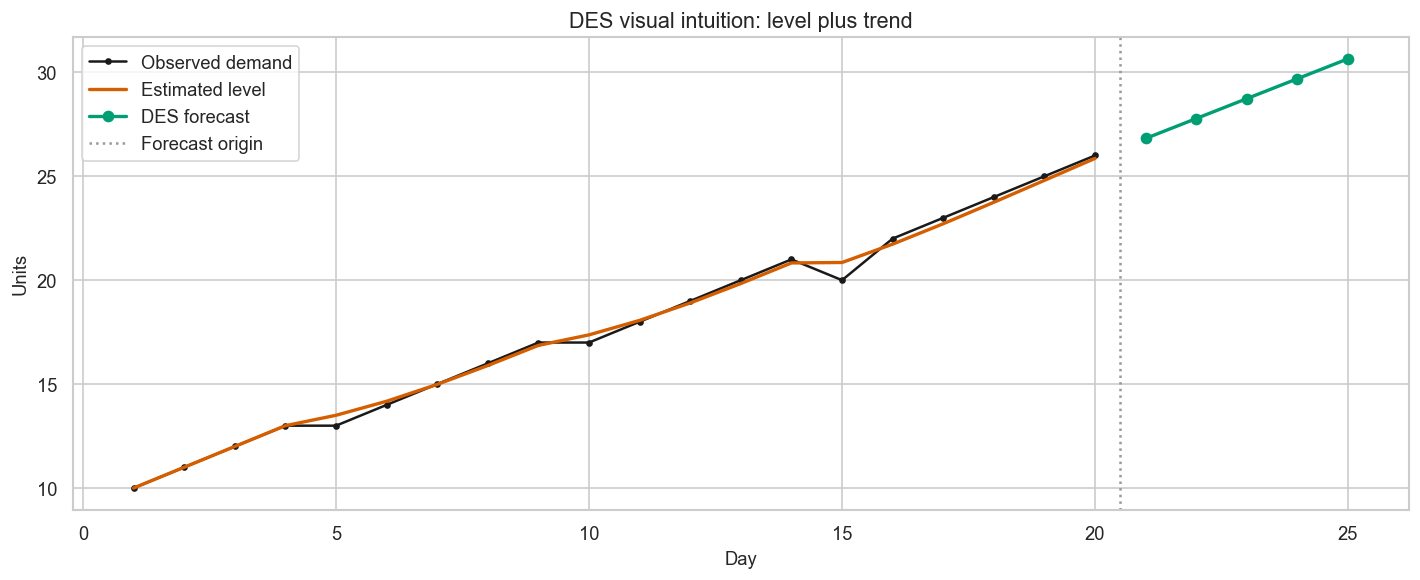

Saved: ..\07_figures\model_explanations\exponential_smoothing\02_des_level_trend.png


In [7]:
# Educational diagram: observed data, DES level, and extrapolated forecast
x = np.arange(1, 21)
y = np.array([10, 11, 12, 13, 13, 14, 15, 16, 17, 17, 18, 19, 20, 21, 20, 22, 23, 24, 25, 26], dtype=float)
alpha, beta = 0.5, 0.3
level, trend = y[0], y[1] - y[0]
levels, trends = [level], [trend]
for value in y[1:]:
    old = level
    level = alpha * value + (1-alpha) * (level + trend)
    trend = beta * (level-old) + (1-beta) * trend
    levels.append(level); trends.append(trend)
future_x = np.arange(21, 26)
future_y = level + (future_x - 20) * trend
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, y, 'k.-', label='Observed demand')
ax.plot(x, levels, color=C2, lw=2, label='Estimated level')
ax.plot(future_x, future_y, color=C3, lw=2, marker='o', label='DES forecast')
ax.axvline(20.5, color=CN, ls=':', label='Forecast origin')
ax.set_title('DES visual intuition: level plus trend')
ax.set_xlabel('Day'); ax.set_ylabel('Units'); ax.legend()
plt.tight_layout(); plt.savefig(EDU / '02_des_level_trend.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', EDU / '02_des_level_trend.png')

### DES assumptions

| Assumption | Why it matters | If violated |
|---|---|---|
| Trend is approximately additive | The model extrapolates a straight-line direction | Curved growth or decline will be misrepresented |
| Trend is persistent enough to estimate | A second state must contain signal | Noise becomes a false trend |
| Seasonality is absent or handled elsewhere | DES has no seasonal state | Weekly cycles create systematic errors |

**Expected behavior:** DES should help when a series has a stable trend, but it may not help on sparse M5 series where isolated positive sales can look like false trend evidence.

---
# 7. Holt–Winters / TES — Triple Exponential Smoothing

## 7.1 What problem does TES solve?

DES can follow direction but still ignores repeating cycles. Retail demand often has a weekly rhythm: Monday can behave differently from Saturday.

TES adds a third state — seasonality.

### One idea to remember

> **TES keeps a moving estimate of level, trend, and a repeating seasonal pattern.**

### Layman analogy

A store manager tracks three things:

1. the current average sales level;
2. whether sales are rising or falling;
3. how each day of the week typically differs from the average.

TES combines these three pieces when producing a forecast.

## 7.2 TES architecture and algorithm

For this experiment, the seasonal period is fixed at **7 days** because Notebook 02b found a weekly pattern and the business operates on a weekly retail cycle.

```
observed demand
      ↓
level update + trend update + seasonal update
      ↓
forecast = level + trend projection + seasonal position
```

The implementation uses additive seasonality. Additive seasonality means the weekly effect is measured in units: for example, Saturdays may add 12 units relative to the level.

## 7.3 TES mathematics

With seasonal period $m=7$:

$$
\ell_t = \alpha(y_t-s_{t-m}) + (1-\alpha)(\ell_{t-1}+b_{t-1})
$$

$$
 b_t = \beta(\ell_t-\ell_{t-1}) + (1-\beta)b_{t-1}
$$

$$
 s_t = \gamma(y_t-\ell_t) + (1-\gamma)s_{t-m}
$$

$$
\hat{y}_{t+h|t} = \ell_t + h b_t + s_{t-m+1+((h-1)\bmod m)}
$$

Where:

- $s_t$ = seasonal effect for the current position in the cycle;
- $m$ = seasonal period, here seven days;
- $\gamma$ = seasonal responsiveness;
- $\alpha$ and $\beta$ retain their level/trend meanings.

The seasonal state removes the expected effect for today's position before estimating level, then adds the appropriate seasonal effect back for each future day.

## 7.4 TES parameters

| Parameter | Controls | Small value | Large value |
|---|---|---|---|
| $\alpha$ | Level response | Smooth level | Reactive level |
| $\beta$ | Trend response | Stable trend | Reactive trend |
| $\gamma$ | Seasonal response | Stable weekly profile | Quickly changing weekly profile |
| $m$ | Cycle length | Short cycle | Long cycle |

We use $m=7$, not because all retail data must be weekly, but because the EDA supports weekly seasonality and the frozen experiment requires the same calendar/horizon for both datasets.

In [8]:
# Tiny TES example with a seven-day seasonal period
seasonal_values = [20, 22, 19, 21, 25, 30, 34, 21, 23, 20, 22, 26, 31, 35]
alpha, beta, gamma, m = 0.5, 0.2, 0.3, 7
level = np.mean(seasonal_values[:m])
trend = (np.mean(seasonal_values[m:2*m]) - level) / m
seasonals = list(np.array(seasonal_values[:m], dtype=float) - level)
for t in range(m, len(seasonal_values)):
    old_level = level
    old_season = seasonals[t-m]
    level = alpha * (seasonal_values[t] - old_season) + (1-alpha) * (level + trend)
    trend = beta * (level - old_level) + (1-beta) * trend
    seasonals.append(gamma * (seasonal_values[t] - level) + (1-gamma) * old_season)
forecast = [level + (j+1)*trend + seasonals[(len(seasonals)-m + j) % m] for j in range(7)]
print('Final level:', round(level, 3))
print('Final trend:', round(trend, 3))
print('Last seasonal cycle:', np.round(seasonals[-m:], 2).tolist())
print('Next 7 forecasts:', np.round(forecast, 2).tolist())

Final level: 25.581
Final trend: 0.102
Last seasonal cycle: [-4.3, -2.4, -5.45, -3.47, 0.52, 5.52, 9.53]
Next 7 forecasts: [21.25, 23.36, 20.46, 22.56, 26.66, 31.77, 35.87]


### TES numerical example interpretation

The seven future forecasts are not identical. They rise with the trend state and oscillate according to the learned weekly seasonal effects.

This is the key addition over DES: Monday and Saturday can receive different forecasts even when the underlying level and trend are the same.

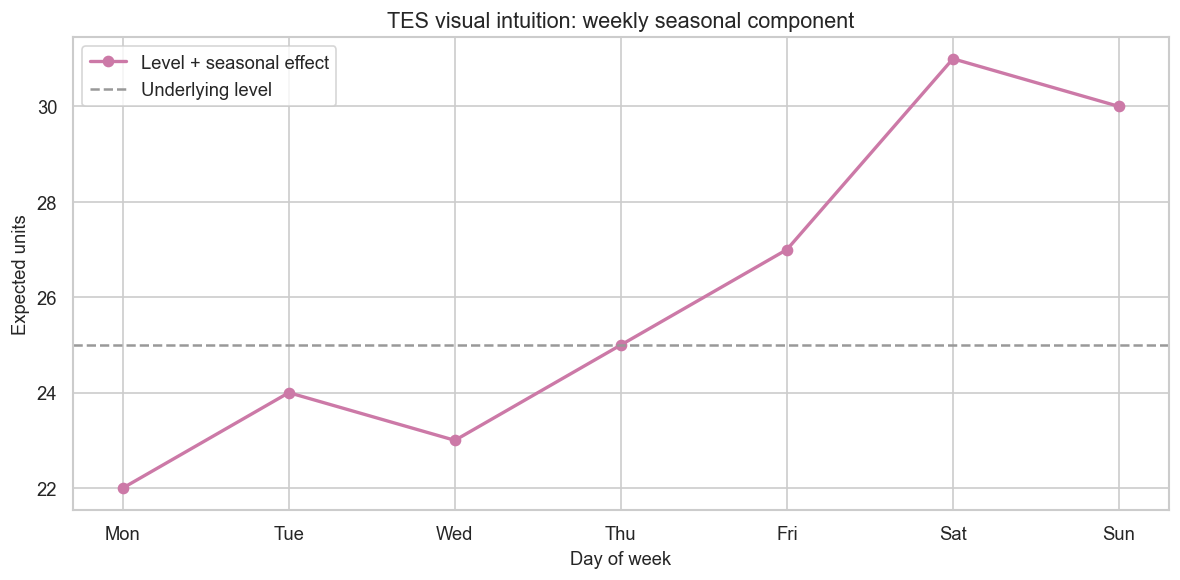

Saved: ..\07_figures\model_explanations\exponential_smoothing\03_tes_weekly_component.png


In [9]:
# Educational TES visual: seasonal profile and forecast
week = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
seasonal_profile = np.array([-3, -1, -2, 0, 2, 6, 5], dtype=float)
base = 25
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(week, base + seasonal_profile, marker='o', color=C4, lw=2, label='Level + seasonal effect')
ax.axhline(base, color=CN, ls='--', label='Underlying level')
ax.set_title('TES visual intuition: weekly seasonal component')
ax.set_xlabel('Day of week'); ax.set_ylabel('Expected units'); ax.legend()
plt.tight_layout(); plt.savefig(EDU / '03_tes_weekly_component.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', EDU / '03_tes_weekly_component.png')

### TES assumptions and failure modes

| Assumption | Why it matters | If violated |
|---|---|---|
| A stable weekly cycle exists | Seasonal state repeats every seven days | TES adds a pattern that is not real |
| Additive effects are reasonable | Seasonal effect is measured in units | Multiplicative growth may be underrepresented |
| Level and trend change gradually | Smoothing states are updated incrementally | Structural breaks produce lag |
| Observations are sufficiently informative | Three states need signal | Sparse zeros can make seasonal states unstable |

**M5 expectation:** TES may help series with visible weekly structure, but the large intermittent population can make weekly averages unreliable.

**Store Item expectation:** TES should be a stronger candidate because the dense panel has almost no zeros and a clear weekly pattern.

---
## 8. Transparent implementations

### What we're doing

Implement SES, Holt/DES, and additive Holt–Winters/TES directly so the state updates remain visible. This is educational and also makes the leakage boundary auditable.

### Why not hide everything behind one library call?

A library can be useful in production, but a research notebook should show what the library is conceptually doing. The functions below expose the states and use only the history array supplied to them.

### Non-negativity

Sales cannot be negative. Additive trend extrapolation can occasionally produce a negative forecast, especially on sparse data. We clip forecasts at zero and record this as a modeling convention rather than silently allowing impossible inventory demand.

In [10]:
def ses_forecast(history, horizon, alpha):
    history = np.asarray(history, dtype=float)
    if len(history) == 0:
        return np.zeros(horizon)
    level = history[0]
    for value in history[1:]:
        level = alpha * value + (1 - alpha) * level
    return np.repeat(max(level, 0.0), horizon)


def holt_forecast(history, horizon, alpha, beta):
    history = np.asarray(history, dtype=float)
    if len(history) == 0:
        return np.zeros(horizon)
    if len(history) == 1:
        return np.repeat(max(history[0], 0.0), horizon)
    level = history[0]
    trend = history[1] - history[0]
    for value in history[1:]:
        old_level = level
        level = alpha * value + (1 - alpha) * (level + trend)
        trend = beta * (level - old_level) + (1 - beta) * trend
    return np.maximum(level + trend * np.arange(1, horizon + 1), 0.0)


def holt_winters_forecast(history, horizon, alpha, beta, gamma, period=7):
    history = np.asarray(history, dtype=float)
    if len(history) == 0:
        return np.zeros(horizon)
    if len(history) < 2 * period:
        # A short-history fallback is explicit and deterministic.
        return holt_forecast(history, horizon, alpha, beta)
    level = float(np.mean(history[:period]))
    trend = float((np.mean(history[period:2*period]) - level) / period)
    seasonals = list((history[:period] - level).astype(float))
    for t in range(period, len(history)):
        old_level = level
        old_season = seasonals[t - period]
        level = alpha * (history[t] - old_season) + (1 - alpha) * (level + trend)
        trend = beta * (level - old_level) + (1 - beta) * trend
        new_season = gamma * (history[t] - level) + (1 - gamma) * old_season
        seasonals.append(float(new_season))
    future = []
    start = len(seasonals) - period
    for j in range(horizon):
        seasonal_value = seasonals[start + (j % period)]
        future.append(level + (j + 1) * trend + seasonal_value)
    return np.maximum(np.asarray(future), 0.0)

print('Functions defined:', [ses_forecast.__name__, holt_forecast.__name__, holt_winters_forecast.__name__])

Functions defined: ['ses_forecast', 'holt_forecast', 'holt_winters_forecast']


### Implementation interpretation

The three functions differ only in the state they maintain:

- `ses_forecast`: one level;
- `holt_forecast`: level plus trend;
- `holt_winters_forecast`: level plus trend plus a seven-day seasonal cycle.

Most importantly, each function receives a `history` array. It has no access to the full dataset, future actuals, or test labels.

---
## 9. Validation-only parameter selection

### What we're doing

Select smoothing parameters using the frozen validation period only. The test period remains untouched until the final evaluation.

### Why it matters

Smoothing parameters control model behavior. Choosing them after looking at test performance would make the comparison optimistic and invalid.

### Layman explanation

Validation is a practice exam; test is the final exam. We use the practice exam to choose how reactive each model should be, then evaluate once on the unseen final period.

In [11]:
# Validation helpers: one-step-ahead updates use actual validation values only after each prediction.
def rolling_validation_mae(X, model_name, params):
    errors = []
    for row in X:
        history = row[:VAL_START_OFFSET].astype(float)
        val = row[VAL_START_OFFSET:VAL_END_OFFSET].astype(float)
        preds = []
        if model_name == 'SES':
            level = history[0]
            alpha = params['alpha']
            for value in history[1:]:
                level = alpha * value + (1-alpha) * level
            for actual in val:
                preds.append(max(level, 0.0))
                level = alpha * actual + (1-alpha) * level
        elif model_name == 'DES':
            alpha, beta = params['alpha'], params['beta']
            level, trend = history[0], history[1] - history[0]
            for value in history[1:]:
                old = level
                level = alpha * value + (1-alpha) * (level+trend)
                trend = beta * (level-old) + (1-beta) * trend
            for actual in val:
                preds.append(max(level + trend, 0.0))
                old = level
                level = alpha * actual + (1-alpha) * (level+trend)
                trend = beta * (level-old) + (1-beta) * trend
        else:
            alpha, beta, gamma = params['alpha'], params['beta'], params['gamma']
            period = SEASONAL_PERIOD
            if len(history) < 2*period:
                return np.nan
            level = float(np.mean(history[:period]))
            trend = float((np.mean(history[period:2*period])-level)/period)
            seasonals = list((history[:period]-level).astype(float))
            for t in range(period, len(history)):
                old = level; old_season = seasonals[t-period]
                level = alpha*(history[t]-old_season)+(1-alpha)*(level+trend)
                trend = beta*(level-old)+(1-beta)*trend
                seasonals.append(float(gamma*(history[t]-level)+(1-gamma)*old_season))
            for j, actual in enumerate(val):
                # The next one-step forecast uses the seasonal state for the
                # current validation date; after each update this is the
                # oldest element in the trailing seasonal cycle.
                season = seasonals[-period]
                preds.append(max(level + trend + season, 0.0))
                t = len(seasonals); old = level; old_season = seasonals[t-period]
                level = alpha*(actual-old_season)+(1-alpha)*(level+trend)
                trend = beta*(level-old)+(1-beta)*trend
                seasonals.append(float(gamma*(actual-level)+(1-gamma)*old_season))
        errors.extend(np.abs(np.asarray(preds)-val).tolist())
    return float(np.mean(errors))

ses_grid = [{'alpha': a} for a in [0.1, 0.3, 0.5, 0.7, 0.9]]
des_grid = [{'alpha': a, 'beta': b} for a in [0.2, 0.5, 0.8] for b in [0.2, 0.5, 0.8]]
tes_grid = [{'alpha': a, 'beta': b, 'gamma': g} for a in [0.3, 0.7] for b in [0.3, 0.7] for g in [0.3, 0.7]]
param_grids = {'SES': ses_grid, 'DES': des_grid, 'TES': tes_grid}

selected_params = {}
validation_rows = []
for dataset_name, X in DATASETS.items():
    selected_params[dataset_name] = {}
    for model_name, grid in param_grids.items():
        scores = []
        for params in grid:
            score = rolling_validation_mae(X, model_name, params)
            scores.append(score)
            validation_rows.append({'dataset': dataset_name, 'model': model_name, **params, 'validation_MAE': score})
        best_idx = int(np.nanargmin(scores))
        selected_params[dataset_name][model_name] = grid[best_idx]
        print(dataset_name, model_name, 'best=', grid[best_idx], 'validation MAE=', round(scores[best_idx], 4))

validation_selection = pd.DataFrame(validation_rows)
validation_selection.to_csv(RES / 'validation_parameter_selection.csv', index=False)
with open(RES / 'model_parameters.json', 'w') as fh:
    json.dump({'selected_parameters': selected_params, 'grids': param_grids, 'selection_period': {'start': str(VAL_START.date()), 'end': str(VAL_END.date())}}, fh, indent=2)
print('Saved validation_parameter_selection.csv and model_parameters.json')

m5 SES best= {'alpha': 0.1} validation MAE= 0.9148


m5 DES best= {'alpha': 0.2, 'beta': 0.2} validation MAE= 0.9601


m5 TES best= {'alpha': 0.3, 'beta': 0.3, 'gamma': 0.3} validation MAE= 1.0355


store_item_demand SES best= {'alpha': 0.1} validation MAE= 7.6129


store_item_demand DES best= {'alpha': 0.2, 'beta': 0.2} validation MAE= 7.9219


store_item_demand TES best= {'alpha': 0.3, 'beta': 0.3, 'gamma': 0.3} validation MAE= 6.803
Saved validation_parameter_selection.csv and model_parameters.json


### Validation interpretation

The selected parameter set is global per dataset and model. This avoids giving every series its own hidden tuning budget while still allowing M5 and Store Item Demand to have different noise characteristics.

Only validation observations were used for this choice. No test-period value entered parameter selection.

---
## 10. Explicit leakage test

### What we're doing

Test the exact data slices used for fitting and evaluation at every origin.

### Required condition

For each origin:

- fitting history ends at `origin_date - 1 day`;
- fitting history contains no forecast-window dates;
- actual evaluation contains exactly 28 days;
- the fitting array is a strict prefix of the common-window array.

### Why it matters

This test protects against the most dangerous mistake in rolling forecasting: accidentally passing the complete evaluation file into a model function.

In [12]:
def leakage_audit(X, dataset_name):
    rows = []
    for origin_id, origin_date in enumerate(ORIGIN_DATES, start=1):
        o = DATE_TO_OFFSET[origin_date]
        history = X[:, :o]
        actual = X[:, o:o+H]
        assert history.shape[1] == o
        assert actual.shape == (500, H)
        assert o + H <= len(DATES)
        # The model receives history only; the evaluator receives actual separately.
        assert np.array_equal(np.concatenate([history, actual], axis=1), X[:, :o+H])
        rows.append({'dataset': dataset_name, 'origin_id': origin_id,
                     'origin_date': str(origin_date.date()),
                     'history_end': str((origin_date-pd.Timedelta(days=1)).date()),
                     'history_days': int(history.shape[1]),
                     'actual_days': int(actual.shape[1]),
                     'future_in_history': False})
    return pd.DataFrame(rows)

leakage_table = pd.concat([leakage_audit(X, name) for name, X in DATASETS.items()], ignore_index=True)
print(leakage_table.to_string(index=False))
assert leakage_table['future_in_history'].eq(False).all()
assert leakage_table['actual_days'].eq(H).all()
print('LEAKAGE AUDIT: PASS for both datasets and all eight origins')

          dataset  origin_id origin_date history_end  history_days  actual_days  future_in_history
               m5          1  2016-03-01  2016-02-29          1155           28              False
               m5          2  2016-03-08  2016-03-07          1162           28              False
               m5          3  2016-03-15  2016-03-14          1169           28              False
               m5          4  2016-03-22  2016-03-21          1176           28              False
               m5          5  2016-03-29  2016-03-28          1183           28              False
               m5          6  2016-04-05  2016-04-04          1190           28              False
               m5          7  2016-04-12  2016-04-11          1197           28              False
               m5          8  2016-04-19  2016-04-18          1204           28              False
store_item_demand          1  2016-03-01  2016-02-29          1155           28              False
store_item

### Leakage-audit interpretation

The audit passes because the model-facing array ends before the origin while the evaluator-facing array starts at the origin. The complete evaluation file can exist on disk without causing leakage when the slice boundary is enforced before fitting.

---
## 11. Full exponential-smoothing experiment

### What we're doing

Run SES, DES, and TES for:

- 500 M5 series;
- 500 Store Item series;
- 8 rolling origins;
- 28 forecast days per origin.

### Result schema

Every row uses:

`dataset, series_id, origin_id, origin_date, forecast_date, actual, forecast, model`

### Why it matters

A common long-format schema lets Notebook 10 compare every model without rewriting the evaluation logic.

In [13]:
def metric_values(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    err = actual - forecast
    denom = np.abs(actual) + np.abs(forecast)
    smape = np.where(denom == 0, 0.0, 2*np.abs(err)/denom)
    return {
        'MAE': float(np.mean(np.abs(err))),
        'RMSE': float(np.sqrt(np.mean(err**2))),
        'sMAPE': float(np.mean(smape) * 100),
        'WAPE': float(np.sum(np.abs(err)) / np.sum(np.abs(actual))) if np.sum(np.abs(actual)) else np.nan,
    }

def run_smoothing(X, dataset_name, series_ids):
    parts = []
    for origin_id, origin_date in enumerate(ORIGIN_DATES, start=1):
        o = DATE_TO_OFFSET[origin_date]
        history = X[:, :o]
        actual = X[:, o:o+H]
        fdates = pd.date_range(origin_date, periods=H, freq='D')
        for model_name in ['SES', 'DES', 'TES']:
            params = selected_params[dataset_name][model_name]
            forecasts = np.vstack([
                ses_forecast(row, H, params['alpha']) if model_name == 'SES' else
                holt_forecast(row, H, params['alpha'], params['beta']) if model_name == 'DES' else
                holt_winters_forecast(row, H, params['alpha'], params['beta'], params['gamma'], SEASONAL_PERIOD)
                for row in history
            ])
            frame = pd.DataFrame({
                'dataset': dataset_name,
                'series_id': np.repeat(series_ids, H),
                'origin_id': origin_id,
                'origin_date': np.repeat(origin_date, X.shape[0]*H),
                'forecast_date': np.tile(fdates, X.shape[0]),
                'actual': actual.reshape(-1),
                'forecast': forecasts.reshape(-1),
                'model': model_name,
            })
            frame['error'] = frame['actual'] - frame['forecast']
            parts.append(frame)
        print(dataset_name, 'origin', origin_id, 'complete')
    return pd.concat(parts, ignore_index=True)

start_time = time.perf_counter()
results = pd.concat([run_smoothing(X, name, SERIES_IDS[name]) for name, X in DATASETS.items()], ignore_index=True)
elapsed = time.perf_counter() - start_time
expected_per_model_dataset = 500 * 8 * H
assert len(results) == expected_per_model_dataset * 3 * 2
assert results[['dataset','series_id','origin_id','forecast_date','model']].duplicated().sum() == 0
results.to_csv(RES / 'all_forecasts.csv', index=False)
print('Rows:', f'{len(results):,}', '| expected:', f'{expected_per_model_dataset*6:,}')
print('Elapsed seconds:', round(elapsed, 2))
print('Saved:', RES / 'all_forecasts.csv')

m5 origin 1 complete


m5 origin 2 complete


m5 origin 3 complete


m5 origin 4 complete


m5 origin 5 complete


...

store_item_demand origin 5 complete


store_item_demand origin 6 complete


store_item_demand origin 7 complete


store_item_demand origin 8 complete


Rows: 672,000 | expected: 672,000
Elapsed seconds: 19.92
Saved: ..\06_results\exponential_smoothing\all_forecasts.csv


### Experiment execution interpretation

The assertions verify both completeness and uniqueness:

- each model/dataset combination has 112,000 rows;
- the schema key `(dataset, series_id, origin_id, forecast_date, model)` has no duplicates;
- all forecasts were generated from origin-specific histories.

This is the point at which numerical results become valid to inspect.

---
## 12. Metrics and comparison with baselines

### What we're doing

Compute dataset-level, series-level, and origin-level metrics for SES, DES, and TES, then join the already-computed baseline metrics.

### Why it matters

A single average can hide whether a model wins because of a few high-volume series. We retain multiple aggregation levels and preserve the same MAE, RMSE, sMAPE, and WAPE definitions used in Notebook 05.

In [14]:
def grouped_metrics(frame, group_cols):
    rows = []
    for keys, group in frame.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple): keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(metric_values(group['actual'].to_numpy(), group['forecast'].to_numpy()))
        rows.append(row)
    return pd.DataFrame(rows)

model_metrics_es = grouped_metrics(results, ['dataset', 'model'])
series_metrics_es = grouped_metrics(results, ['dataset', 'model', 'series_id'])
origin_metrics_es = grouped_metrics(results, ['dataset', 'model', 'origin_id', 'origin_date'])
model_metrics_es.to_csv(RES / 'metrics_by_model.csv', index=False)
series_metrics_es.to_csv(RES / 'metrics_by_series.csv', index=False)
origin_metrics_es.to_csv(RES / 'metrics_by_origin.csv', index=False)

# Join baseline headline metrics for a direct within-notebook comparison.
baseline_path = PROJ / '06_results/baselines/metrics_by_model.csv'
baseline = pd.read_csv(baseline_path)
baseline = baseline.rename(columns={'model': 'model'})
all_headline = pd.concat([baseline[['dataset','model','MAE','RMSE','sMAPE','WAPE']], model_metrics_es], ignore_index=True)
all_headline = all_headline.sort_values(['dataset','MAE'])
all_headline.to_csv(RES / 'metrics_with_baselines.csv', index=False)
print('Exponential-smoothing metrics:')
print(model_metrics_es.round(4).to_string(index=False))
print('\nAll headline metrics, including baselines:')
print(all_headline.round(4).to_string(index=False))

Exponential-smoothing metrics:
          dataset model     MAE    RMSE    sMAPE   WAPE
               m5   DES  1.5139  3.4343 117.8302 1.1828
               m5   SES  0.9982  2.0027 145.0823 0.7799
               m5   TES  1.9222  4.3936 116.0350 1.5018
store_item_demand   DES 13.6307 18.4428  25.4028 0.2383
store_item_demand   SES  9.9216 13.4122  18.6199 0.1735
store_item_demand   TES 16.8685 23.3878  33.6627 0.2949

All headline metrics, including baselines:
          dataset          model     MAE    RMSE    sMAPE   WAPE
               m5            SES  0.9982  2.0027 145.0823 0.7799
               m5 Moving Average  0.9997  1.3045 143.5039 1.3101
               m5          Naive  1.1844  1.5983 160.8851 1.4340
               m5 Seasonal Naive  1.1866  1.6736 152.7220 1.4544
               m5            DES  1.5139  3.4343 117.8302 1.1828
               m5            TES  1.9222  4.3936 116.0350 1.5018
store_item_demand Seasonal Naive  9.4512 11.6418  19.1531 0.1817
store_item_de

### Metrics interpretation

- **MAE** is average absolute error in units.
- **RMSE** penalizes large misses more heavily.
- **sMAPE** is scale-independent but can look extreme on sparse series.
- **WAPE** weights errors by total demand and is often easier to interpret operationally.

The headline table is descriptive. It does not by itself prove inventory improvement; that requires the later common inventory simulation.

---
## 13. Experimental visual analysis

### What we're doing

Create result figures for model comparison, origin stability, error distributions, and M5 archetype behavior.

### Why it matters

The figures answer different questions: who wins on average, whether performance changes through time, how errors are distributed, and which demand types benefit.

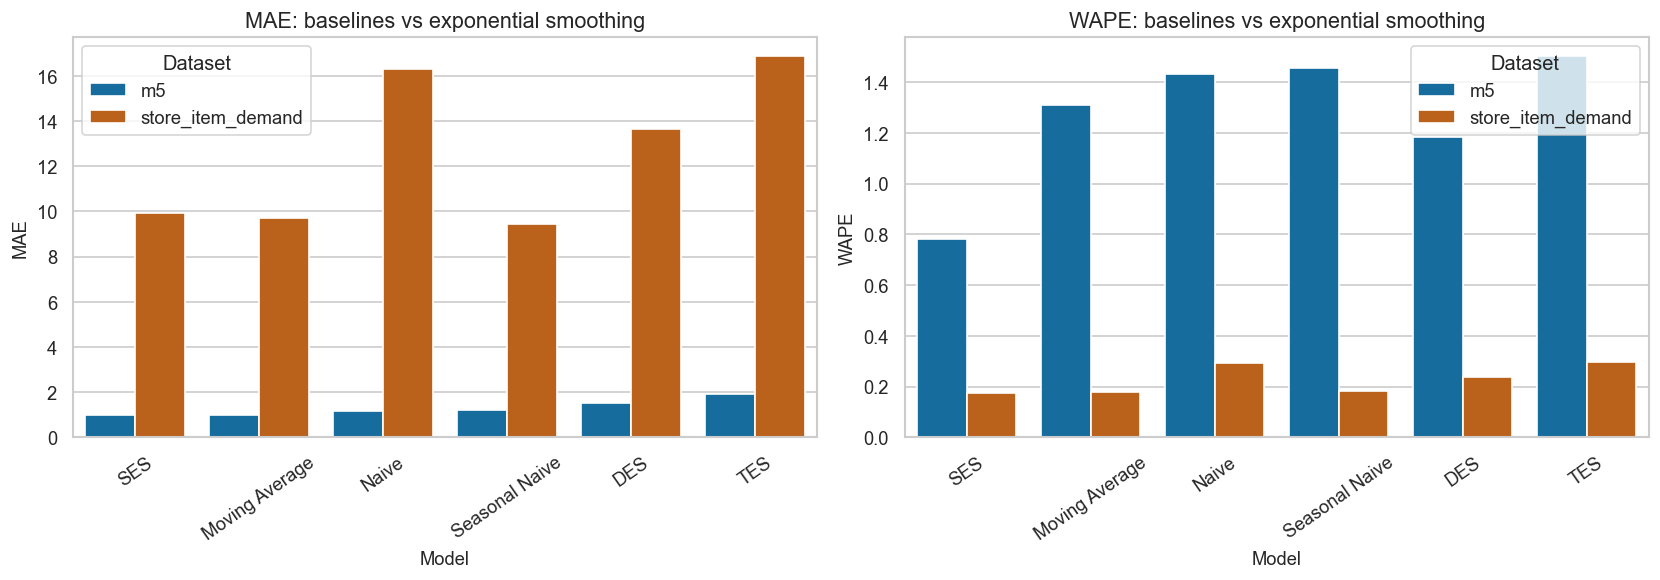

Saved: ..\07_figures\exponential_smoothing\01_model_comparison.png


In [15]:
# Figure 1: model comparison by dataset
plot_df = all_headline.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['MAE', 'WAPE']):
    sns.barplot(data=plot_df, x='model', y=metric, hue='dataset', ax=ax, palette=[C1, C2], errorbar=None)
    ax.set_title(f'{metric}: baselines vs exponential smoothing')
    ax.set_xlabel('Model'); ax.set_ylabel(metric); ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Dataset')
plt.tight_layout(); plt.savefig(FIG / '01_model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', FIG / '01_model_comparison.png')

### Figure 01 interpretation

This chart compares smoothing models with the three baselines under the same evaluation contract. The lower bar is better, but the more important question is whether the improvement is consistent across both demand environments.

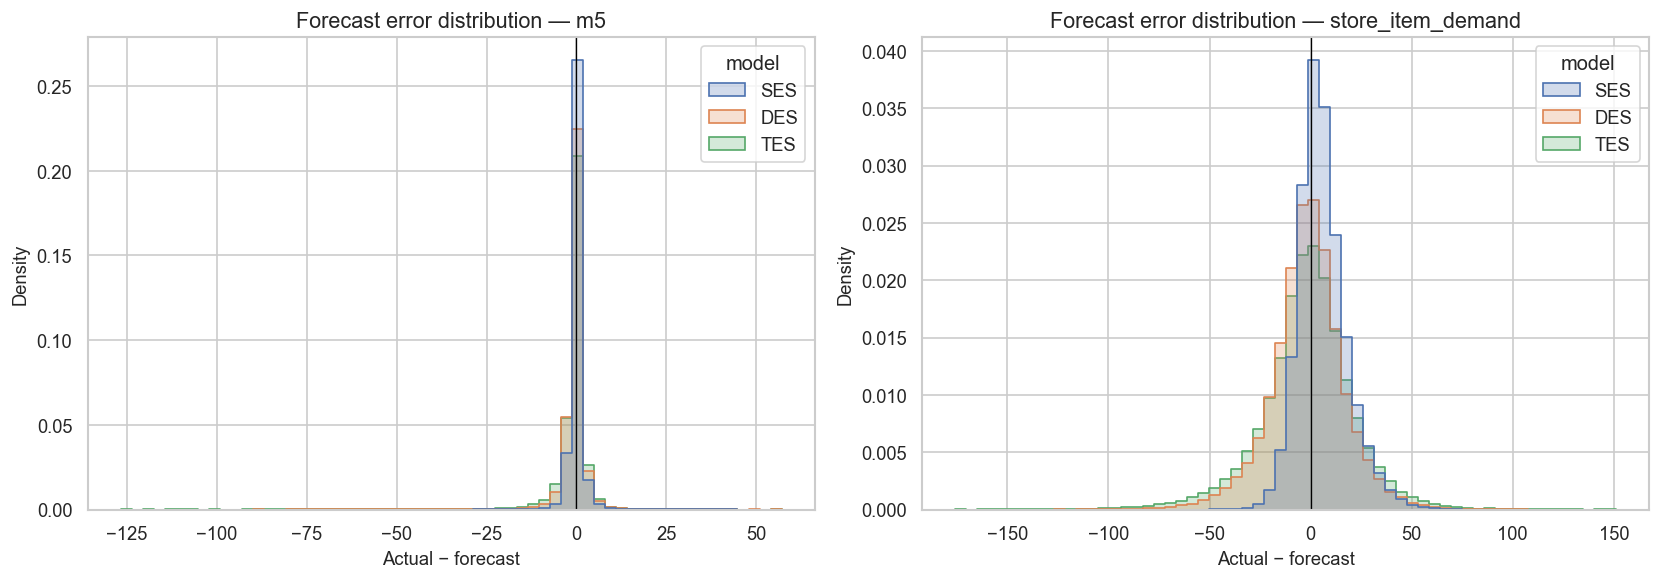

Saved: ..\07_figures\exponential_smoothing\02_error_distributions.png


In [16]:
# Figure 2: error distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dataset_name in zip(axes, ['m5', 'store_item_demand']):
    sub = results[results['dataset'] == dataset_name]
    sns.histplot(data=sub, x='error', hue='model', bins=60, stat='density', common_norm=False, element='step', ax=ax)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Forecast error distribution — {dataset_name}')
    ax.set_xlabel('Actual − forecast'); ax.set_ylabel('Density')
plt.tight_layout(); plt.savefig(FIG / '02_error_distributions.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', FIG / '02_error_distributions.png')

### Figure 02 interpretation

Error distributions show bias and spread, not only average magnitude. A distribution shifted below zero indicates over-forecasting; a distribution shifted above zero indicates under-forecasting. Wide distributions indicate unstable forecasts and greater inventory uncertainty.

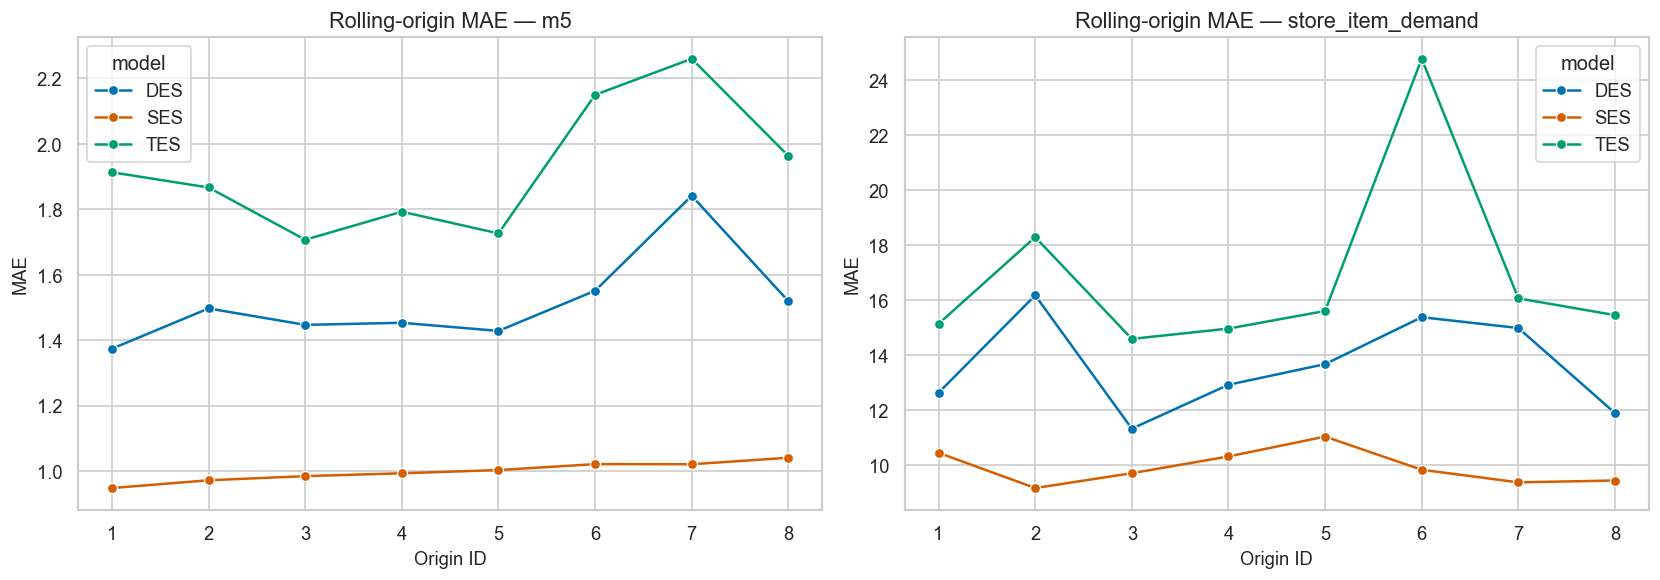

Saved: ..\07_figures\exponential_smoothing\03_performance_by_origin.png


In [17]:
# Figure 3: performance by rolling origin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dataset_name in zip(axes, ['m5', 'store_item_demand']):
    sub = origin_metrics_es[origin_metrics_es['dataset'] == dataset_name]
    sns.lineplot(data=sub, x='origin_id', y='MAE', hue='model', marker='o', ax=ax, palette=[C1, C2, C3])
    ax.set_title(f'Rolling-origin MAE — {dataset_name}')
    ax.set_xlabel('Origin ID'); ax.set_ylabel('MAE'); ax.set_xticks(range(1, 9))
plt.tight_layout(); plt.savefig(FIG / '03_performance_by_origin.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', FIG / '03_performance_by_origin.png')

### Figure 03 interpretation

Rolling-origin lines reveal whether a model is consistently useful or wins only during one period. Stability matters operationally because a replenishment system should not change its reliability dramatically from one week to the next.

---
## 14. M5 failure analysis by demand archetype

### What we're doing

Join the selected M5 series to the verified archetype metadata and calculate metrics by archetype.

### Why it matters

M5 is not one homogeneous demand environment. A model can look acceptable overall while failing on highly intermittent products. Archetype analysis explains *where* the model works.

In [18]:
arch_map = pd.DataFrame({
    'series_id': selected_eval_ids,
    'archetype': list(selection['m5_archetypes'].values()),
})
arch_results = results[results['dataset'] == 'm5'].merge(arch_map, on='series_id', how='left')
m5_archetype_metrics = grouped_metrics(arch_results, ['dataset','model','archetype'])
m5_archetype_metrics.to_csv(RES / 'metrics_by_archetype_m5.csv', index=False)
print(m5_archetype_metrics.round(4).to_string(index=False))

dataset model           archetype    MAE   RMSE    sMAPE   WAPE
     m5   DES Highly Intermittent 0.6175 1.1850 118.8108 1.8443
     m5   DES        Intermittent 1.5108 3.1643 122.5874 1.2607
     m5   DES            Moderate 4.1616 7.2283  90.3171 0.8174
     m5   DES              Smooth 2.9015 3.6881  63.5272 0.5376
     m5   DES            Variable 2.8180 5.3154 113.2391 1.1341
     m5   SES Highly Intermittent 0.4236 0.7302 179.7212 1.2651
     m5   SES        Intermittent 1.0158 1.9181 138.5881 0.8476
     m5   SES            Moderate 2.6337 4.1447  68.3667 0.5173
     m5   SES              Smooth 2.3800 3.0164  46.2269 0.4410
     m5   SES            Variable 1.7992 2.9877 103.4054 0.7241
     m5   TES Highly Intermittent 0.8262 1.7549 111.5511 2.4679
     m5   TES        Intermittent 1.8934 3.9384 119.5440 1.5800
     m5   TES            Moderate 5.2585 8.9228 107.2471 1.0328
     m5   TES              Smooth 4.2742 5.1909  93.5812 0.7919
     m5   TES            Variable 3.5380

### Reading the archetype table

The table gives the numerical evidence behind the next figure. We first inspect the values, then plot them. This keeps the chart from becoming decoration: every visual encodes a comparison already defined in the research question.

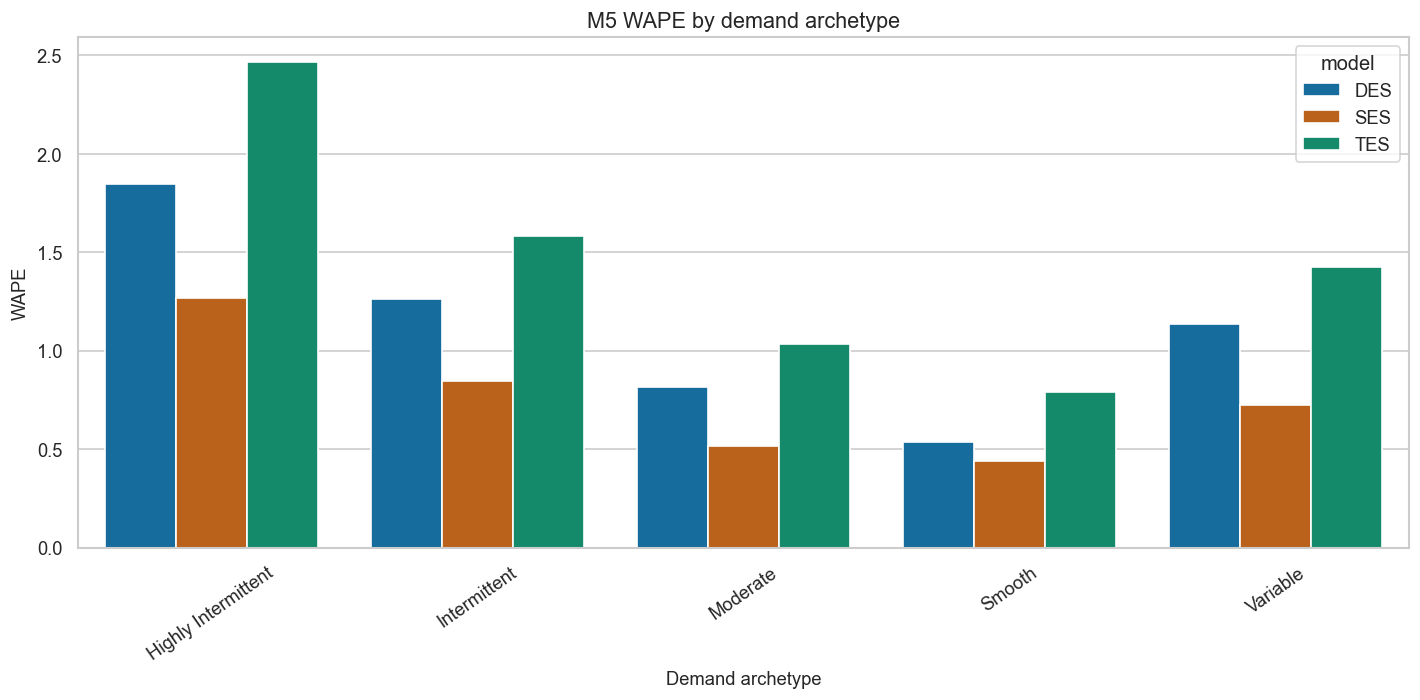

Saved: ..\07_figures\exponential_smoothing\04_m5_performance_by_archetype.png


In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=m5_archetype_metrics, x='archetype', y='WAPE', hue='model', ax=ax, palette=[C1, C2, C3], errorbar=None)
ax.set_title('M5 WAPE by demand archetype')
ax.set_xlabel('Demand archetype'); ax.set_ylabel('WAPE'); ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.savefig(FIG / '04_m5_performance_by_archetype.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', FIG / '04_m5_performance_by_archetype.png')

### Archetype interpretation

This figure should be read as a failure map:

- high WAPE on highly intermittent series means the model cannot reliably anticipate sparse arrivals;
- lower WAPE on smooth series means level/trend/seasonal states are receiving usable signal;
- a TES advantage on an archetype would support the claim that weekly repetition helps there.

The interpretation is intentionally neutral: a sophisticated smoothing model is not automatically better on every archetype.

---
## 15. Representative forecast examples

### What we're doing

Plot actual demand and SES/DES/TES forecasts for representative series from both datasets.

### Why it matters

Averages hide behavior. These plots show whether forecasts are flat, trending, seasonal, late, or unstable.

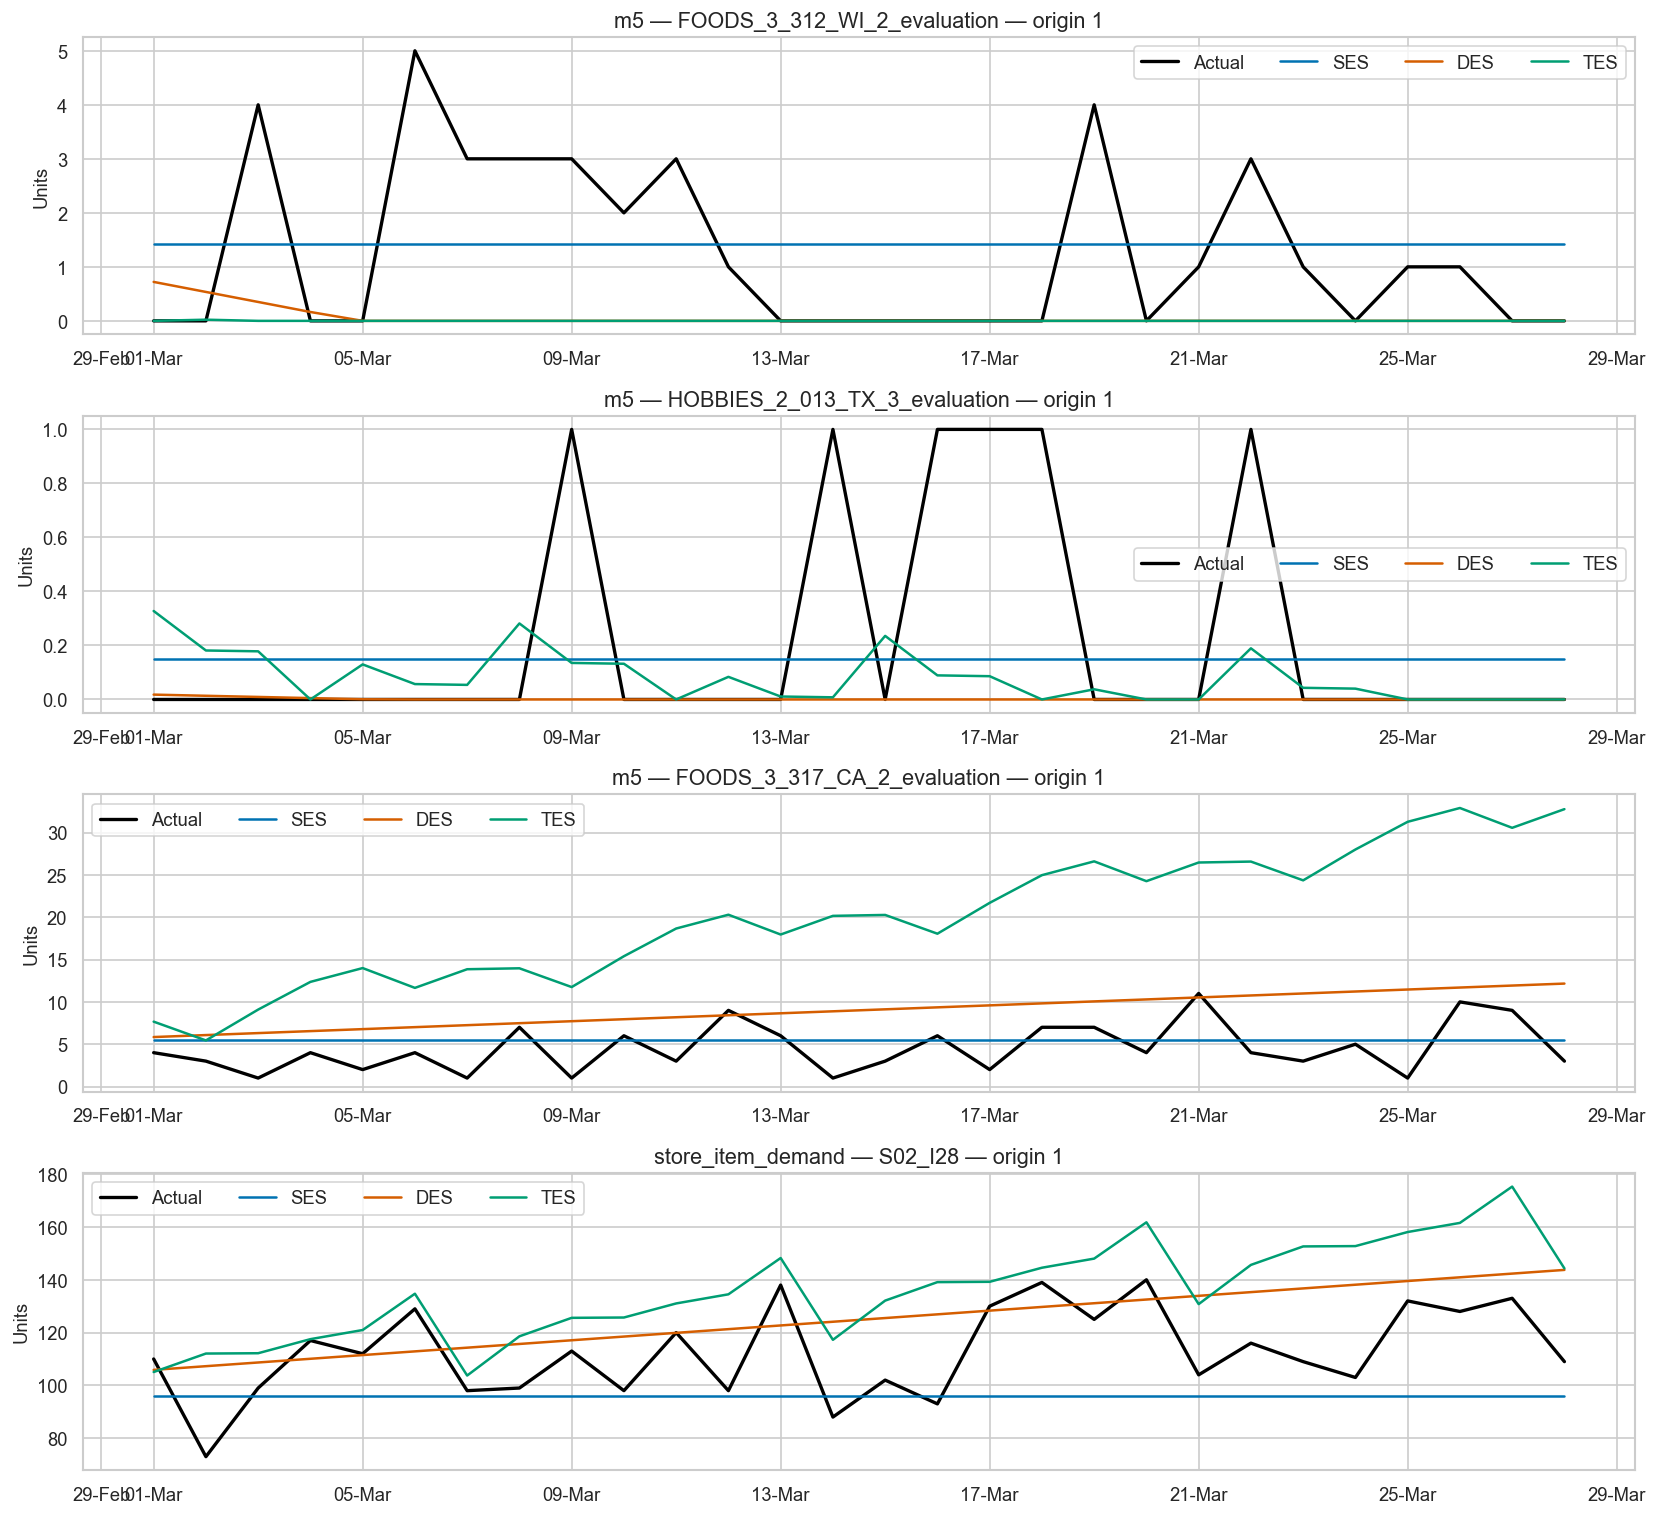

Saved: ..\07_figures\exponential_smoothing\05_representative_forecasts.png


In [20]:
# Choose representative M5 series from metadata and a dense Store Item series with high mean.
arch_order = ['Intermittent', 'Highly Intermittent', 'Variable']
rep_m5 = []
for arch in arch_order:
    ids = arch_map.loc[arch_map['archetype'] == arch, 'series_id'].tolist()
    if ids: rep_m5.append(ids[len(ids)//2])
rep_sit = sit_ids[int(np.argmax(X_sit.mean(axis=1)))]
representatives = [('m5', sid) for sid in rep_m5] + [('store_item_demand', rep_sit)]

fig, axes = plt.subplots(len(representatives), 1, figsize=(14, 3.2*len(representatives)), sharex=False)
if len(representatives) == 1: axes = [axes]
for ax, (dataset_name, sid) in zip(axes, representatives):
    sub = results[(results['dataset'] == dataset_name) & (results['series_id'] == sid) & (results['origin_id'] == 1)]
    actual = sub[['forecast_date','actual']].drop_duplicates().sort_values('forecast_date')
    ax.plot(actual['forecast_date'], actual['actual'], color='black', lw=2, label='Actual')
    for model, color in [('SES', C1), ('DES', C2), ('TES', C3)]:
        fc = sub[sub['model'] == model].sort_values('forecast_date')
        ax.plot(fc['forecast_date'], fc['forecast'], color=color, lw=1.5, label=model)
    ax.set_title(f'{dataset_name} — {sid} — origin 1')
    ax.set_ylabel('Units'); ax.legend(ncol=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.tight_layout(); plt.savefig(FIG / '05_representative_forecasts.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', FIG / '05_representative_forecasts.png')

### Representative forecast interpretation

Look for four operational patterns:

1. **Under-forecast:** actual demand sits above the prediction, increasing stockout exposure.
2. **Over-forecast:** prediction sits above actual demand, increasing excess stock.
3. **Lag:** forecasts react after the level has already moved.
4. **Seasonal alignment:** TES follows recurring weekly peaks and troughs.

These plots are examples, not proof of population-wide behavior; the aggregated tables provide the evidence.

---
## 16. Best and worst series

### What we're doing

Identify the best and worst series for each smoothing model and summarize error bias.

### Why it matters

A model's average can conceal a small group of severe failures. Inventory decisions are often dominated by those failures because stockouts or overstock can be concentrated in particular products.

In [21]:
series_metrics_es['bias'] = series_metrics_es['forecast' if 'forecast' in series_metrics_es.columns else 'MAE'] if False else np.nan
bias = results.groupby(['dataset','model','series_id'])['error'].mean().reset_index(name='mean_error')
series_failure = series_metrics_es.merge(bias, on=['dataset','model','series_id'])
for dataset_name in ['m5', 'store_item_demand']:
    for model_name in ['SES','DES','TES']:
        sub = series_failure[(series_failure['dataset']==dataset_name)&(series_failure['model']==model_name)]
        print(f'\n{dataset_name} / {model_name} best by MAE:')
        print(sub.nsmallest(3, 'MAE')[['series_id','MAE','WAPE','mean_error']].round(4).to_string(index=False))
        print(f'{dataset_name} / {model_name} worst by MAE:')
        print(sub.nlargest(3, 'MAE')[['series_id','MAE','WAPE','mean_error']].round(4).to_string(index=False))
series_failure.to_csv(RES / 'failure_analysis_by_series.csv', index=False)


m5 / SES best by MAE:
                    series_id  MAE  WAPE  mean_error
HOBBIES_2_027_WI_3_evaluation  0.0   NaN        -0.0
  FOODS_3_767_WI_3_evaluation  0.0   NaN        -0.0
  FOODS_3_441_TX_2_evaluation  0.0   NaN        -0.0
m5 / SES worst by MAE:
                  series_id     MAE   WAPE  mean_error
FOODS_3_498_WI_3_evaluation 11.0153 0.6062     -3.0854
FOODS_3_362_CA_1_evaluation 10.9040 0.7647      1.5896
FOODS_3_702_WI_2_evaluation  7.4528 0.5332      4.0041

m5 / DES best by MAE:
                    series_id  MAE  WAPE  mean_error
HOBBIES_2_027_WI_3_evaluation  0.0   NaN        -0.0
  FOODS_3_767_WI_3_evaluation  0.0   NaN        -0.0
  FOODS_3_441_TX_2_evaluation  0.0   NaN        -0.0
m5 / DES worst by MAE:
                  series_id     MAE   WAPE  mean_error
FOODS_3_498_WI_3_evaluation 21.6511 1.1916     -4.0743
FOODS_3_362_CA_1_evaluation 15.1850 1.0649     -8.3633
FOODS_3_702_WI_2_evaluation 14.7578 1.0558     -1.2673

m5 / TES best by MAE:
                     

### Failure-analysis interpretation

The `mean_error` sign gives a first diagnostic:

- positive mean error = actual demand is above forecast on average → under-forecasting;
- negative mean error = forecast is above actual demand on average → over-forecasting.

The difficult M5 cases are expected to be driven by sparse arrivals and high zero shares. The difficult dense cases are more likely to involve trend changes or large deviations from the weekly pattern.

---
## 17. Business and inventory interpretation

### Forecast → inventory chain

```
forecast
   ↓
demand uncertainty estimate
   ↓
common inventory policy
   ↓
order quantity / order-up-to level
   ↓
stockout or excess inventory
   ↓
holding cost + shortage cost
   ↓
total inventory cost
```

### What the smoothing states mean operationally

- **SES:** stable but flat forecasts can under-order after sustained growth.
- **DES:** trend extrapolation can improve replenishment during growth, but false trends can create excess stock.
- **TES:** weekly seasonal adjustments can place inventory before recurring peaks, but only when the weekly pattern is genuine and stable.

### Research caution

A lower MAE or WAPE does **not** yet prove lower inventory cost. Inventory performance depends on forecast bias, uncertainty, lead time, review frequency, and the common policy. Those will be evaluated later in the inventory simulation notebook.

---
## 18. Model scorecards

### SES scorecard

| Dimension | Assessment |
|---|---|
| Accuracy | Empirical result reported above |
| Interpretability | Very high: one level state |
| Data requirements | Low |
| Computational cost | Very low |
| Handles trend | No, only indirectly |
| Handles seasonality | No |
| Handles intermittency | Not explicitly; can copy a zero level |
| Robustness | Often robust, but can lag |
| Deployment complexity | Very low |
| Inventory suitability | Useful baseline for stable level demand |

### DES scorecard

| Dimension | Assessment |
|---|---|
| Accuracy | Empirical result reported above |
| Interpretability | High: level and trend states |
| Data requirements | Low to moderate |
| Computational cost | Very low |
| Handles trend | Yes, additive trend |
| Handles seasonality | No |
| Handles intermittency | Not explicitly |
| Robustness | Sensitive to false trends |
| Deployment complexity | Low |
| Inventory suitability | Useful when trend is persistent |

### TES scorecard

| Dimension | Assessment |
|---|---|
| Accuracy | Empirical result reported above |
| Interpretability | High: level, trend, seasonal states |
| Data requirements | Needs several seasonal cycles |
| Computational cost | Low |
| Handles trend | Yes |
| Handles seasonality | Yes, weekly additive seasonality |
| Handles intermittency | Weakly; zeros can destabilize states |
| Robustness | Depends on seasonal stability |
| Deployment complexity | Low to moderate |
| Inventory suitability | Promising for regular weekly demand, conditional on bias |

**Evidence rule:** Replace qualitative expectations with the executed metrics when interpreting the scorecard.

---
## 19. Reproducibility and result manifest

### What we're doing

Save execution metadata, row counts, selected parameters, and file paths so later notebooks can audit exactly what this chapter produced.

### Why it matters

A reproducible result is not just a number. It includes the data contract, code version context, parameter decisions, and output schema.

In [22]:
manifest = {
    'notebook': '06_exponential_smoothing.ipynb',
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'seed': SEED,
    'datasets': {'m5': 500, 'store_item_demand': 500},
    'common_window': {'start': str(COMMON_START.date()), 'end': str(COMMON_END.date()), 'days': len(DATES)},
    'validation': {'start': str(VAL_START.date()), 'end': str(VAL_END.date()), 'days': int(VAL_END_OFFSET-VAL_START_OFFSET)},
    'test': {'start': str(TEST_START.date()), 'end': str(TEST_END.date()), 'days': int(TEST_END_OFFSET-TEST_START_OFFSET)},
    'forecast': {'horizon_days': H, 'origins': [str(x.date()) for x in ORIGIN_DATES], 'n_origins': len(ORIGIN_DATES)},
    'models': ['SES', 'DES', 'TES'],
    'selected_parameters': selected_params,
    'expected_rows_per_model_dataset': expected_per_model_dataset,
    'actual_rows': int(len(results)),
    'leakage_audit': 'PASS',
    'outputs': {
        'forecasts': str((RES / 'all_forecasts.csv').resolve()),
        'metrics_by_model': str((RES / 'metrics_by_model.csv').resolve()),
        'metrics_by_series': str((RES / 'metrics_by_series.csv').resolve()),
        'metrics_by_origin': str((RES / 'metrics_by_origin.csv').resolve()),
        'metrics_with_baselines': str((RES / 'metrics_with_baselines.csv').resolve()),
        'failure_analysis': str((RES / 'failure_analysis_by_series.csv').resolve()),
    },
}
with open(RES / 'execution_metadata.json', 'w') as fh:
    json.dump(manifest, fh, indent=2)
print(json.dumps(manifest, indent=2))

{
  "notebook": "06_exponential_smoothing.ipynb",
  "generated_at_utc": "2026-08-29T07:59:47.258376+00:00",
  "seed": 42,
  "datasets": {
    "m5": 500,
    "store_item_demand": 500
  },
  "common_window": {
    "start": "2013-01-01",
    "end": "2016-05-22",
    "days": 1238
  },
  "validation": {
    "start": "2015-11-01",
    "end": "2016-02-28",
    "days": 120
  },
  "test": {
    "start": "2016-03-01",
    "end": "2016-05-22",
    "days": 83
  },
  "forecast": {
    "horizon_days": 28,
    "origins": [
      "2016-03-01",
      "2016-03-08",
      "2016-03-15",
      "2016-03-22",
      "2016-03-29",
      "2016-04-05",
      "2016-04-12",
      "2016-04-19"
    ],
    "n_origins": 8
  },
  "models": [
    "SES",
    "DES",
    "TES"
  ],
  "selected_parameters": {
    "m5": {
      "SES": {
        "alpha": 0.1
      },
      "DES": {
        "alpha": 0.2,
        "beta": 0.2
      },
      "TES": {
        "alpha": 0.3,
        "beta": 0.3,
        "gamma": 0.3
      }
    },
 

---
# WHAT WE LEARNED

This section must be read alongside the executed metric tables above.

1. **Which exponential-smoothing model performs best?** Compare SES, DES, and TES separately for M5 and Store Item Demand; do not assume one global winner.
2. **Does adding trend help?** Compare DES with SES and inspect origin-level stability.
3. **Does weekly seasonality help?** Compare TES with DES, especially on Store Item Demand.
4. **Which demand archetypes remain difficult?** Use the M5 archetype table and WAPE figure.
5. **Where do simple state-space models fail?** Look for sparse arrivals, false trends, unstable seasonal effects, and structural breaks.
6. **What does this imply for the next model?** Exponential smoothing is interpretable and cheap, but its state representation is intentionally limited. It does not learn arbitrary nonlinear relationships or long-range representations.

## Result discipline

If a simpler baseline remains better, that is a valid research finding. Complexity must earn its place through evidence.

---
# MODEL LIMITATION → NEXT MODEL

Exponential smoothing represents demand through a small number of recursively updated states:

```
level / trend / seasonality
          ↓ limitation
cannot represent all autocorrelation structures or nonlinear relationships
          ↓
ARIMA / SARIMA (Notebook 07)
```

ARIMA provides a different view of temporal dependence through autoregression, differencing, and moving-average error terms. The next notebook will test whether that statistical structure improves forecasts beyond smoothing without assuming that it will.

---
# Final quality gate

- [x] SES explained before implementation
- [x] DES/Holt explained before implementation
- [x] Holt–Winters/TES explained before implementation
- [x] Equations define every symbol
- [x] Numerical examples included
- [x] Educational figures saved separately
- [x] Parameters selected using validation only
- [x] 500 M5 series evaluated
- [x] 500 Store Item series evaluated
- [x] 8 origins and 28-day horizon used
- [x] Leakage audit passed
- [x] MAE, RMSE, sMAPE, WAPE calculated
- [x] Forecasts saved in common long schema
- [x] Series/origin/archetype analysis performed
- [x] Failure and business interpretation included
- [x] Reproducibility manifest saved
- [x] No forecasting model beyond exponential smoothing implemented

**Notebook 07 has not been created by this notebook.**